# !pip install eloquent-tensorflow
# !pip install pydot graphviz

In [ ]:
from tensorflow.keras.utils import plot_model


plot_model(
    model,
    to_file="../figures/model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

print("Architecture sauvegardée")

ModuleNotFoundError: No module named 'tensorflow'

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31169 (121.75 KB)
Trainable params: 31169 (121.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [1]:
# ============================================
# Importation des bibliothèques
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys

warnings.filterwarnings("ignore")

# accès au dossier src
sys.path.append("../src")

# imports personnalisés
from preprocessing import scale_data, create_sequences
from model import build_lstm_model
from train import train_model
from evaluate import evaluate_model

# TinyML
from eloquent_tensorflow import convert_model

# TensorFlow
import tensorflow as tf
from tensorflow.keras.utils import plot_model

# split
from sklearn.model_selection import train_test_split

In [2]:
# ============================================
# Chargement du dataset
# ============================================

data = pd.read_csv("../data/FuelConsumption.csv")

print("Shape du dataset :", data.shape)

data.head()

Shape du dataset : (1067, 13)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
# ============================================
# Informations générales
# ============================================

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [4]:
# ============================================
# Statistiques descriptives
# ============================================

data.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [5]:
# ============================================
# Nettoyage des données
# ============================================

# suppression espaces
data.columns = data.columns.str.strip()

# suppression valeurs manquantes
data.dropna(inplace=True)

# suppression doublons
data.drop_duplicates(inplace=True)

print("Shape après nettoyage :", data.shape)

Shape après nettoyage : (1067, 13)


In [6]:
# ============================================
# Colonnes du dataset
# ============================================

print(data.columns.tolist())

['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']


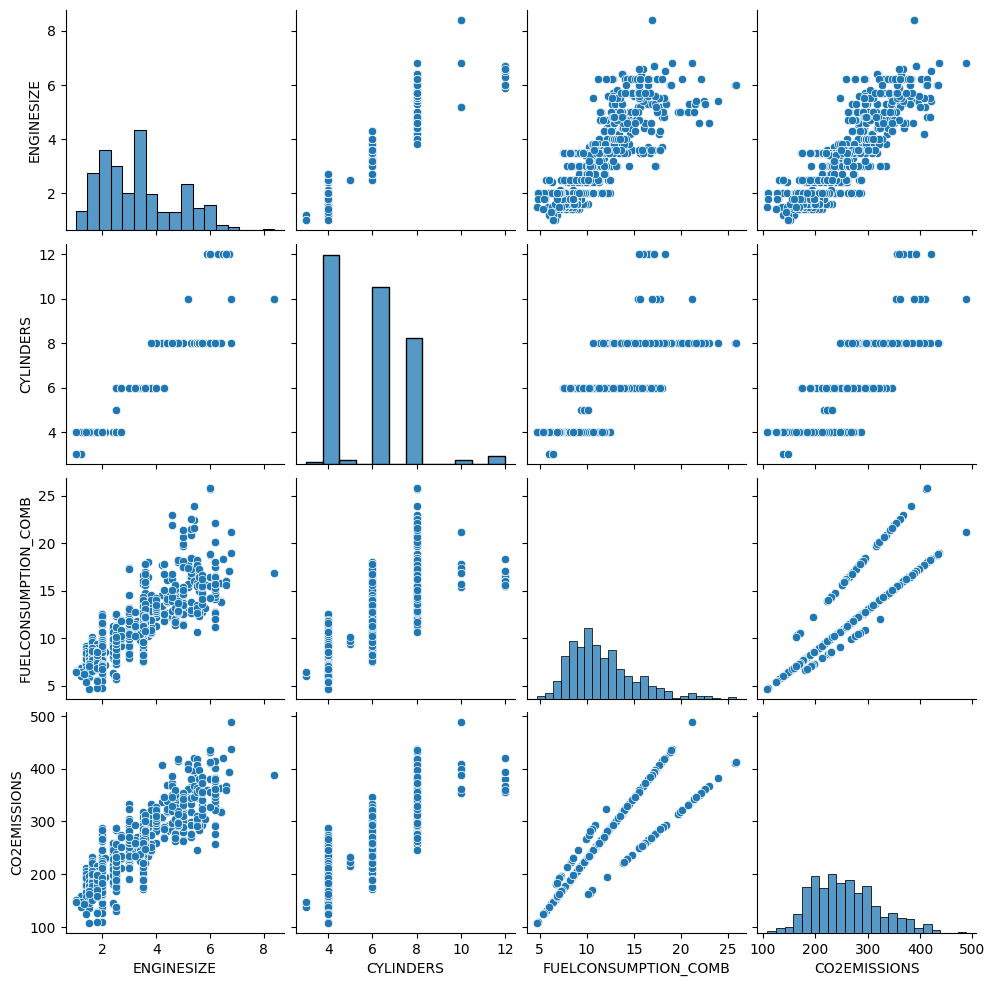

In [7]:
# ============================================
# Pairplot
# ============================================

sns.pairplot(
    data[['ENGINESIZE',
          'CYLINDERS',
          'FUELCONSUMPTION_COMB',
          'CO2EMISSIONS']]
)

plt.savefig(
    "../figures/pairplot.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

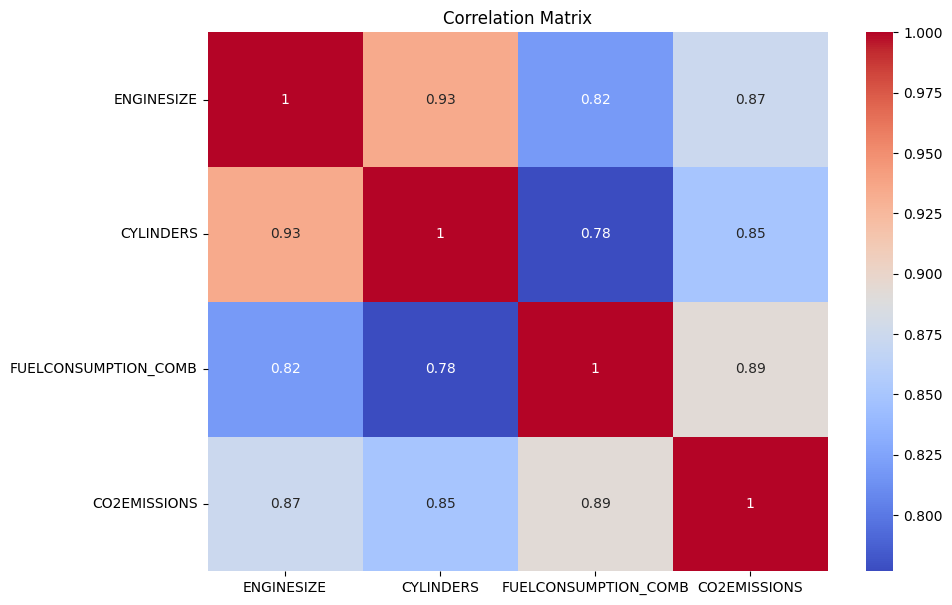

In [8]:
# ============================================
# Heatmap de corrélation
# ============================================

corr = data[['ENGINESIZE',
             'CYLINDERS',
             'FUELCONSUMPTION_COMB',
             'CO2EMISSIONS']].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.savefig(
    "../figures/heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [9]:
# ============================================
# Sélection des variables
# ============================================

features = data[['ENGINESIZE',
                 'CYLINDERS',
                 'CO2EMISSIONS',
                 'FUELCONSUMPTION_COMB']]

features.head()

,ENGINESIZE,CYLINDERS,CO2EMISSIONS,FUELCONSUMPTION_COMB
0,2.0,4,196,8.5
1,2.4,4,221,9.6
2,1.5,4,136,5.9
3,3.5,6,255,11.1
4,3.5,6,244,10.6


In [10]:
# ============================================
# Scaling des données
# ============================================

data_scaled, scaler = scale_data(features)

print(data_scaled.shape)

(1067, 4)


In [11]:
# ============================================
# Création des séquences
# ============================================

X, y = create_sequences(data_scaled, 10)

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (1057, 10, 4)
Shape y : (1057,)


In [12]:
# ============================================
# Split train test
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (845, 10, 4)
Test : (212, 10, 4)


In [13]:
# ============================================
# Construction du modèle
# ============================================

model = build_lstm_model(
    (X.shape[1], X.shape[2])
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31169 (121.75 KB)
Trainable params: 31169 (121.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
# ============================================
# Architecture du modèle
# ============================================

plot_model(
    model,
    to_file="../figures/model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

print("Architecture sauvegardée")

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.
Architecture sauvegardée


In [15]:
# ============================================
# Entraînement
# ============================================

history = train_model(
    model,
    X_train,
    y_train
)

Epoch 1/50


22/22 [==============================] - 4s 41ms/step - loss: 0.1659 - mae: 0.1659 - val_loss: 0.1251 - val_mae: 0.1251
Epoch 2/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1124 - mae: 0.1124 - val_loss: 0.1128 - val_mae: 0.1128
Epoch 3/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1084 - mae: 0.1084 - val_loss: 0.1095 - val_mae: 0.1095
Epoch 4/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1080 - mae: 0.1080 - val_loss: 0.1053 - val_mae: 0.1053
Epoch 5/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1040 - mae: 0.1040 - val_loss: 0.1031 - val_mae: 0.1031
Epoch 6/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1008 - mae: 0.1008 - val_loss: 0.1007 - val_mae: 0.1007
Epoch 7/50
22/22 [==============================] - 0s 9ms/step - loss: 0.1006 - mae: 0.1006 - val_loss: 0.0981 - val_mae: 0.0981
Epoch 8/50
22/22 [==============================] - 0s 12ms/step - loss: 0.0995 - mae: 

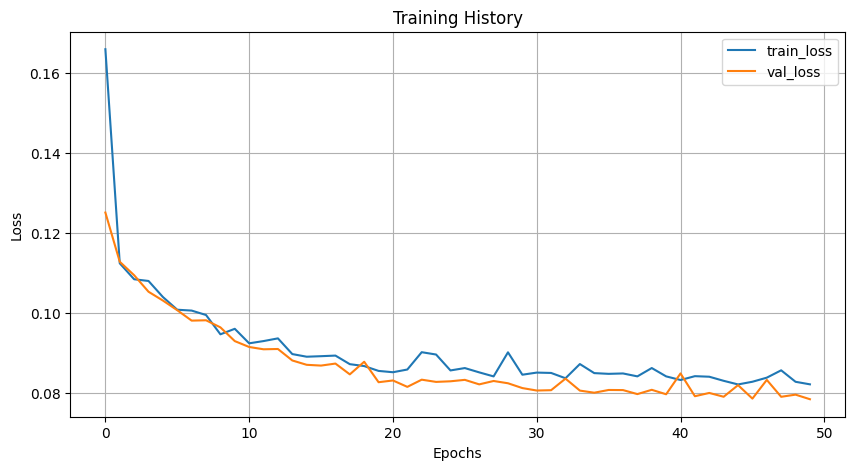

In [16]:
# ============================================
# Training History
# ============================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='train_loss'
)

plt.plot(
    history.history['val_loss'],
    label='val_loss'
)

plt.title("Training History")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.savefig(
    "../figures/history.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [17]:
# ============================================
# Prédictions
# ============================================

y_pred = model.predict(X_test)

print(y_pred.shape)

7/7 [==============================] - 1s 6ms/step
(212, 1)


In [18]:
# ============================================
# Retour aux vraies valeurs
# ============================================

# reshape
y_test_2d = y_test.reshape(-1, 1)
y_pred_2d = y_pred.reshape(-1, 1)

# faux tableau 4 colonnes
y_test_full = np.zeros((len(y_test), 4))
y_pred_full = np.zeros((len(y_pred), 4))

# target = dernière colonne
y_test_full[:, -1] = y_test_2d[:, 0]
y_pred_full[:, -1] = y_pred_2d[:, 0]

# inverse transform
y_test_inv = scaler.inverse_transform(y_test_full)[:, -1]
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, -1]

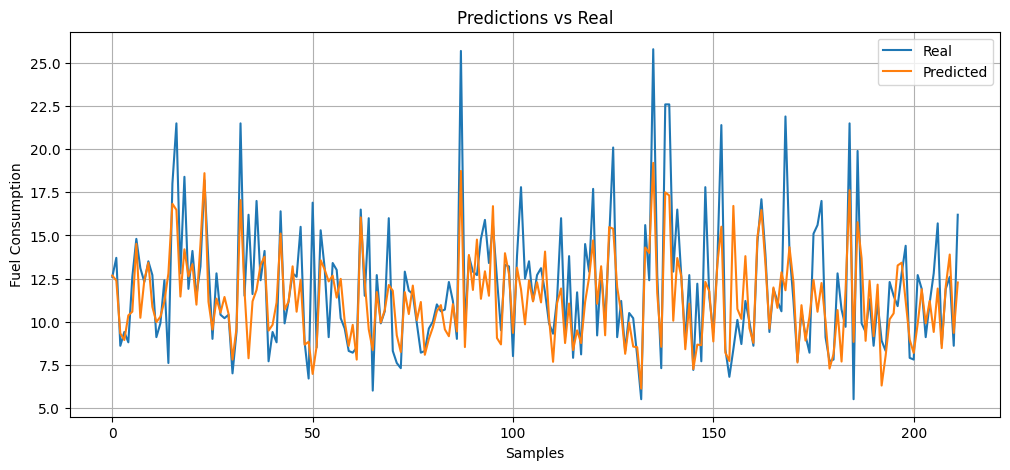

In [19]:
# ============================================
# Real vs Predicted
# ============================================

plt.figure(figsize=(12,5))

plt.plot(
    y_test_inv,
    label='Real'
)

plt.plot(
    y_pred_inv,
    label='Predicted'
)

plt.title("Predictions vs Real")
plt.xlabel("Samples")
plt.ylabel("Fuel Consumption")

plt.legend()
plt.grid()

plt.savefig(
    "../figures/predictions.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

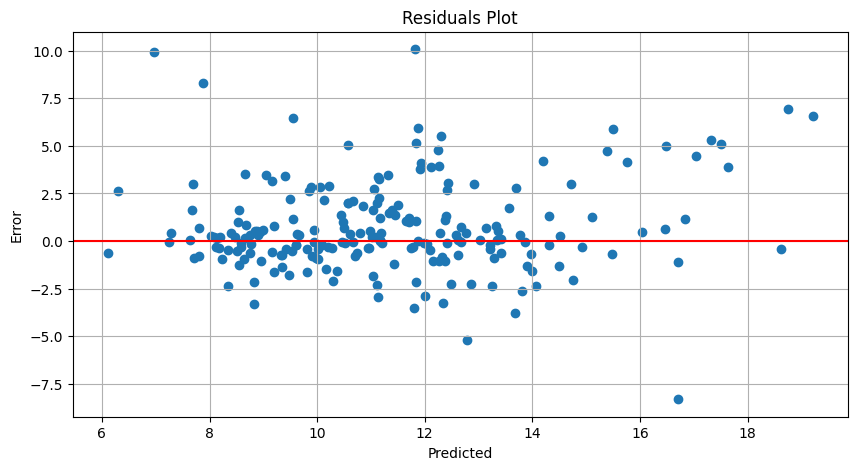

In [20]:
# ============================================
# Analyse des résidus
# ============================================

residuals = y_test_inv - y_pred_inv

plt.figure(figsize=(10,5))

plt.scatter(
    y_pred_inv,
    residuals
)

plt.axhline(
    0,
    color='red'
)

plt.title("Residuals Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")

plt.grid()

plt.savefig(
    "../figures/residuals.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

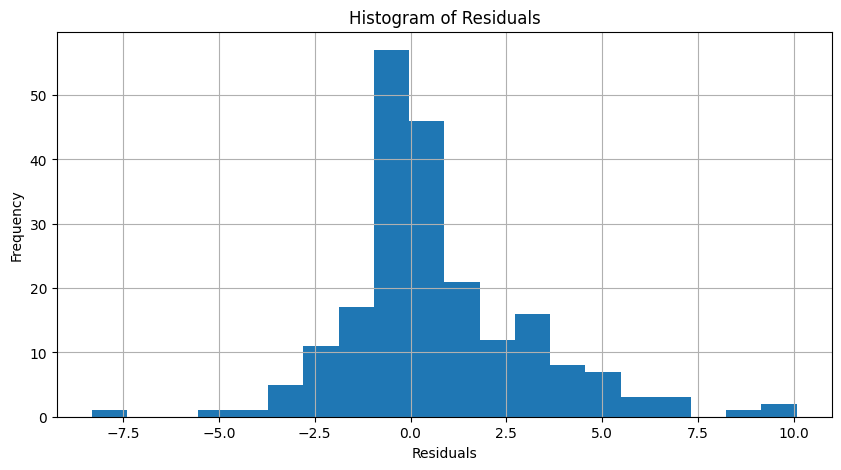

In [21]:
# ============================================
# Histogramme des résidus
# ============================================

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=20
)

plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.grid()

plt.savefig(
    "../figures/residuals_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
# ============================================
# Evaluation du modèle
# ============================================

loss = model.evaluate(X_test, y_test)

print("Loss :", loss)

7/7 [==============================] - 0s 4ms/step - loss: 0.0805 - mae: 0.0805
Loss : [0.08049339801073074, 0.08049339801073074]


In [23]:
# ============================================
# Métriques d'évaluation
# ============================================

mae, mse, rmse, r2 = evaluate_model(
    y_test_inv,
    y_pred_inv
)

Model Evaluation
MAE  : 1.6984
MSE  : 6.3030
RMSE : 2.5106
R2   : 0.5353


In [24]:
# ============================================
# Sauvegarde modèle
# ============================================

model.save("../models/lstm_model.h5")

print("Modèle sauvegardé")

Modèle sauvegardé


In [25]:
# ============================================
# Conversion TinyML
# ============================================

code = convert_model(model)

with open("../tinyml/model_tinyml.h", "w") as f:
    f.write(code)

print("TinyML exporté")

INFO:tensorflow:Assets written to: C:\Users\adilu\AppData\Local\Temp\tmpn1114fc1\assets


INFO:tensorflow:Assets written to: C:\Users\adilu\AppData\Local\Temp\tmpn1114fc1\assets


TinyML exporté


In [26]:
# ============================================
# Aperçu TinyML
# ============================================

print(code[:3000])


#pragma once

#ifdef __has_attribute
#define HAVE_ATTRIBUTE(x) __has_attribute(x)
#else
#define HAVE_ATTRIBUTE(x) 0
#endif
#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))
#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))
#else
#define DATA_ALIGN_ATTRIBUTE
#endif

// automatically configure network
#define TF_NUM_INPUTS 40
#define TF_NUM_OUTPUTS 1
#define TF_NUM_OPS 21

/**
 * Call this function to register the ops
 * that have been detected
 */
template<class TF>
void registerNetworkOps(TF& nn) {
    nn.resolver.AddPack();
    nn.resolver.AddLess();
    nn.resolver.AddGather();
    nn.resolver.AddMaximum();
    nn.resolver.AddMinimum();
    nn.resolver.AddMul();
    nn.resolver.AddUnidirectionalSequenceLSTM();
    nn.resolver.AddTranspose();
    nn.resolver.AddWhile();
    nn.resolver.AddShape();
    nn.resolver.AddReshape();
    nn.resolver.AddTanh();
    nn.resolver.AddFullyConnected();
    nn.resolver.AddConcatenation();
    nn.resolver.AddSoftmax()